# Interpretabilidad — SHAP

**Objetivo:** entender POR QUÉ el modelo LightGBM toma cada decisión.

**¿Qué es SHAP?**
SHAP (SHapley Additive exPlanations) asigna a cada feature un valor que representa
cuánto contribuyó a la predicción de un caso específico.
A diferencia del feature importance del notebook anterior (que solo dice "esta variable importa"),
SHAP dice "esta variable empujó la predicción hacia arriba o hacia abajo, y en cuánto".

**¿Por qué importa en crédito?**
- Regulatorio: los bancos deben poder explicar por qué rechazaron a un cliente
- Debugging: permite detectar si el modelo aprendió patrones incorrectos
- Negocio: permite identificar qué acciones puede tomar un cliente para mejorar su perfil

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import shap
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42
DATA_PATH = '../data/raw/application_train.csv'

print(f'SHAP version: {shap.__version__}')
print(f'LightGBM version: {lgb.__version__}')

SHAP version: 0.45.1
LightGBM version: 4.3.0


## 1. Reproducir el modelo LightGBM

Repetimos exactamente el mismo preprocesamiento y entrenamiento del notebook 03
para tener el modelo disponible en este contexto.

In [2]:
df = pd.read_csv(DATA_PATH)

# Mismo preprocesamiento que notebook 03
missing_pct = df.isnull().mean()
cols_to_drop = missing_pct[missing_pct > 0.4].index.tolist()
df = df.drop(columns=cols_to_drop)

df['AGE_YEARS'] = df['DAYS_BIRTH'].abs() / 365
df = df.drop(columns=['DAYS_BIRTH'])

df['FLAG_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

df = df.drop(columns=['SK_ID_CURR'])

cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = df[col].astype('category')

X = df.drop(columns=['TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

# Mismo modelo que notebook 03
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

print(f'Modelo entrenado. Árboles usados: {model.best_iteration_}')

[100]	valid_0's auc: 0.753176
[200]	valid_0's auc: 0.755528
[300]	valid_0's auc: 0.755867
Modelo entrenado. Árboles usados: 345


## 2. Calcular valores SHAP

Usamos una muestra del test set para que el cálculo sea rápido.
SHAP sobre 61k filas puede tardar varios minutos — con 2,000 filas es suficiente
para obtener conclusiones representativas.

In [3]:
X_sample = X_test.sample(n=2000, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# LightGBM con TreeExplainer devuelve lista [clase_0, clase_1]
# Nos quedamos con clase 1 (probabilidad de incumplimiento)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print(f'Shape SHAP values: {sv.shape}')
print(f'Features: {X_sample.shape[1]}, Muestras: {X_sample.shape[0]}')

Shape SHAP values: (2000, 72)
Features: 72, Muestras: 2000


## 3. Summary Plot — visión global del modelo

El summary plot muestra las features más importantes Y cómo afectan la predicción.
Cada punto es un cliente. El color indica el valor de la feature (rojo=alto, azul=bajo).
El eje X indica si esa feature empujó la predicción hacia incumplimiento (+) o hacia pago (-).

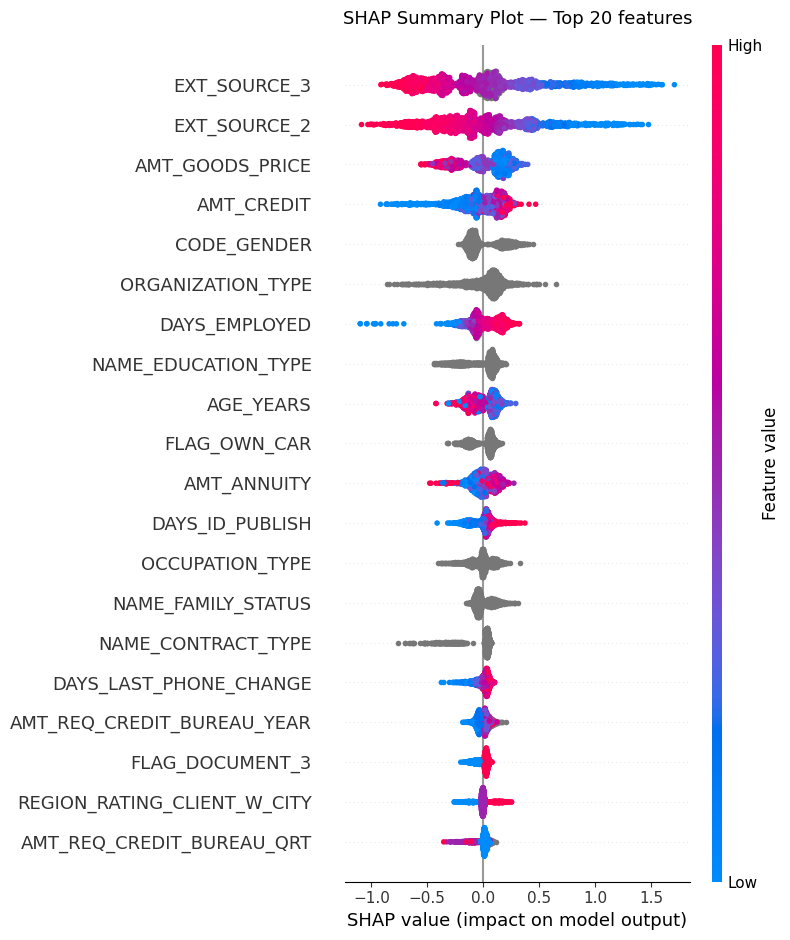

In [4]:
plt.figure()
shap.summary_plot(sv, X_sample, max_display=20, show=False)
plt.title('SHAP Summary Plot — Top 20 features', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

## 4. Bar Plot — importancia media absoluta

Versión simplificada del summary: ordena features por impacto promedio absoluto.
Más fácil de leer para reportar a stakeholders no técnicos.

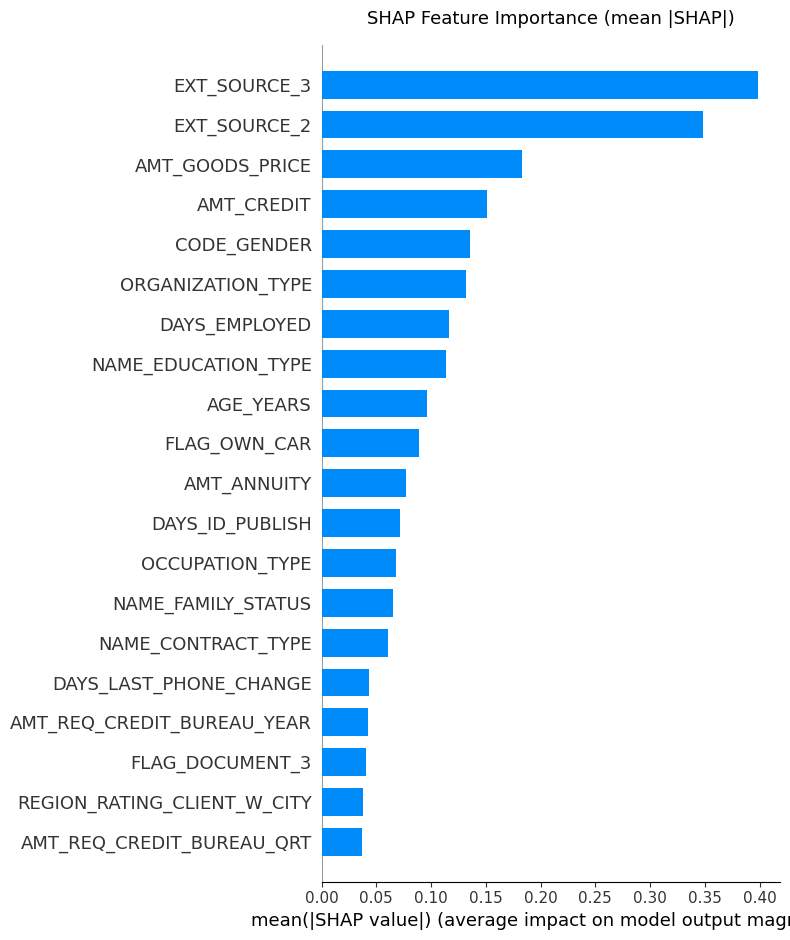

In [5]:
plt.figure()
shap.summary_plot(sv, X_sample, plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance (mean |SHAP|)', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

## 5. Waterfall Plot — explicación de un cliente individual

El waterfall plot explica la predicción de UN solo cliente.
Muestra qué features lo empujaron hacia incumplimiento y cuáles lo alejaron.
Esto es lo que le mostrarías a un oficial de crédito para justificar una decisión.

Cliente seleccionado: índice 1035
Probabilidad de incumplimiento: 0.9152


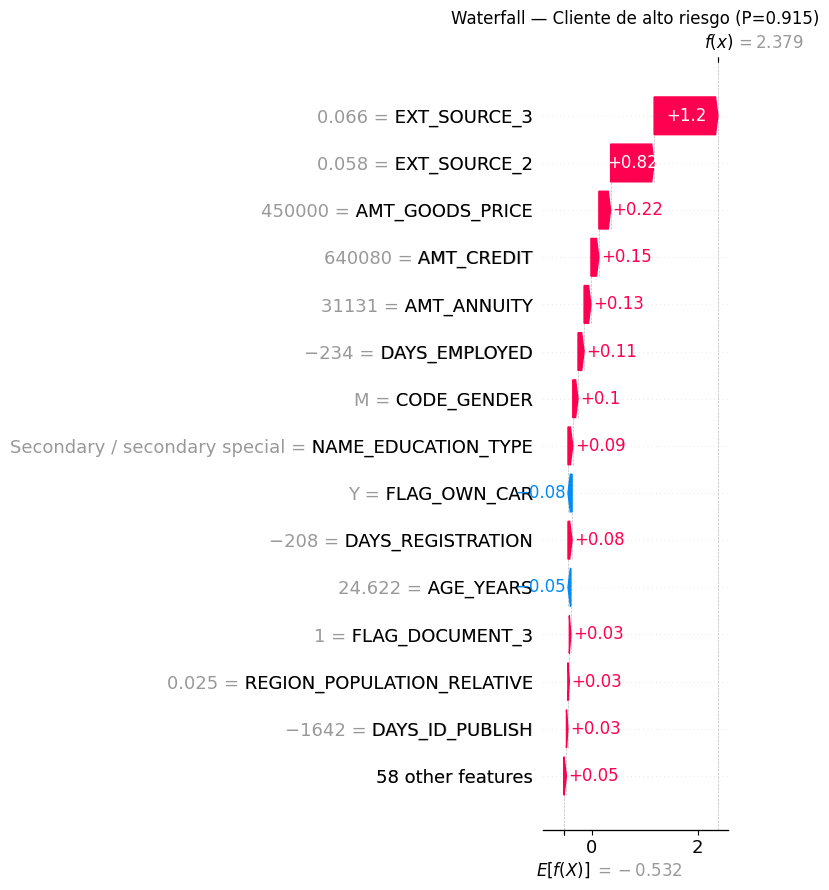

In [6]:
y_proba_sample = model.predict_proba(X_sample)[:, 1]

# Elegimos un cliente con alta probabilidad de incumplimiento (caso interesante)
high_risk_idx = np.argmax(y_proba_sample)
print(f'Cliente seleccionado: índice {high_risk_idx}')
print(f'Probabilidad de incumplimiento: {y_proba_sample[high_risk_idx]:.4f}')

explanation = shap.Explanation(
    values=sv[high_risk_idx],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    data=X_sample.iloc[high_risk_idx].values,
    feature_names=X_sample.columns.tolist()
)

plt.figure()
shap.waterfall_plot(explanation, max_display=15, show=False)
plt.title(f'Waterfall — Cliente de alto riesgo (P={y_proba_sample[high_risk_idx]:.3f})', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Dependence Plot — EXT_SOURCE_2

El dependence plot muestra la relación entre el valor de una feature y su impacto SHAP.
Elegimos EXT_SOURCE_2 porque fue la más importante en el notebook 03.
El color representa una segunda feature que interactúa con ella.

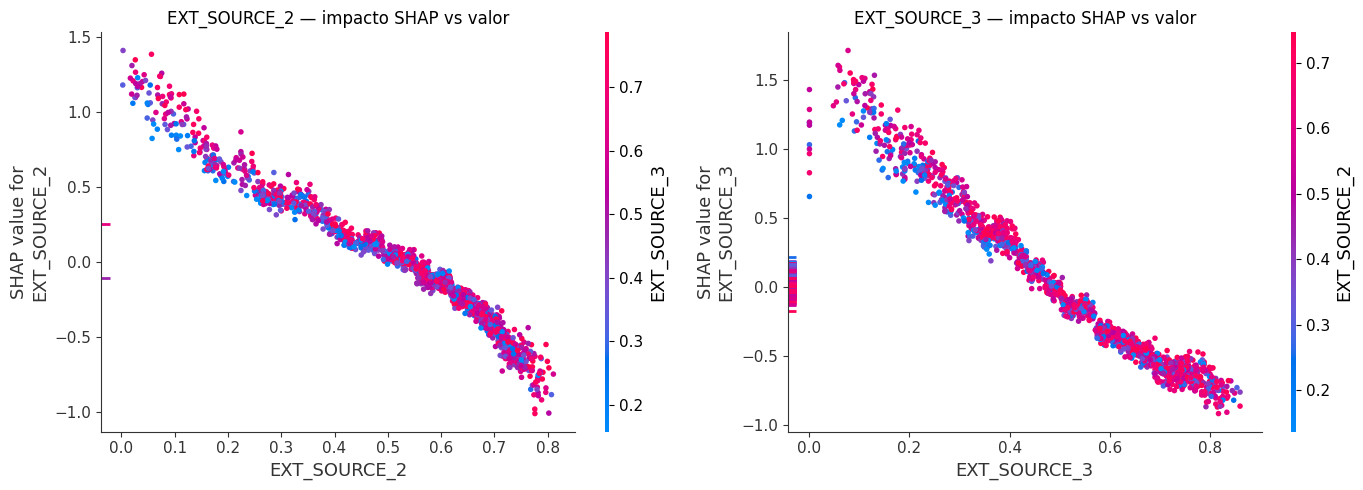

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shap.dependence_plot(
    'EXT_SOURCE_2', sv, X_sample,
    interaction_index='EXT_SOURCE_3',
    ax=axes[0], show=False
)
axes[0].set_title('EXT_SOURCE_2 — impacto SHAP vs valor', fontsize=12)

shap.dependence_plot(
    'EXT_SOURCE_3', sv, X_sample,
    interaction_index='EXT_SOURCE_2',
    ax=axes[1], show=False
)
axes[1].set_title('EXT_SOURCE_3 — impacto SHAP vs valor', fontsize=12)

plt.tight_layout()
plt.show()

## 7. Resumen de hallazgos SHAP

In [8]:
shap_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_abs_shap': np.abs(sv).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('=== TOP 10 FEATURES POR IMPACTO SHAP ===')
print(shap_importance.head(10).to_string(index=False))
print()
print('Interpretación:')
print('  mean_abs_shap = impacto promedio de esa feature en la predicción final')
print('  Un valor de 0.05 significa que esa feature mueve la predicción ~5 puntos porcentuales en promedio')

=== TOP 10 FEATURES POR IMPACTO SHAP ===
            feature  mean_abs_shap
       EXT_SOURCE_3       0.398761
       EXT_SOURCE_2       0.348391
    AMT_GOODS_PRICE       0.182896
         AMT_CREDIT       0.151173
        CODE_GENDER       0.135195
  ORGANIZATION_TYPE       0.132261
      DAYS_EMPLOYED       0.116597
NAME_EDUCATION_TYPE       0.113642
          AGE_YEARS       0.096423
       FLAG_OWN_CAR       0.089403

Interpretación:
  mean_abs_shap = impacto promedio de esa feature en la predicción final
  Un valor de 0.05 significa que esa feature mueve la predicción ~5 puntos porcentuales en promedio
